# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 7: Dataset Credit Scoring**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

import warnings
warnings.filterwarnings("ignore")

from datetime import datetime

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s07")

np.random.seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## **1. Base de Datos**
El dataset corresponde a una **institución financiera privada** que opera en el segmento de créditos de consumo y préstamos personales. La compañía ofrece productos financieros orientados a personas naturales, evaluando su capacidad de pago y perfil de riesgo antes de otorgar cualquier financiamiento.

Cuando un cliente solicita un préstamo, la institución recopila información socioeconómica, historial crediticio y comportamiento financiero a través de un formulario de solicitud. Con estos datos, la empresa busca **automatizar y optimizar el proceso de evaluación crediticia**, determinando si un cliente tiene el perfil adecuado para ser elegible y, más aún, si representa un riesgo de incumplimiento (*default*).

El dataset contiene **2,000 registros** (la información del cliente al momento del alta) y **29 variables** que cubren características sociodemográficas, de capacidad de pago y de comportamiento crediticio histórico del solicitante.

### 📊 **Variables del Dataset**

| **Variable** | **Descripción** |
|---|---|
| `Customer_ID` 🆔 | Identificador único del cliente o solicitante. |
| `Age` 🎂 | Edad del cliente en años. |
| `Income_INR` 💰 | Ingreso anual del cliente (en rupias indias). |
| `Employment_Years` 💼 | Años de experiencia laboral del cliente. |
| `Marital_Status` 💍 | Estado civil del cliente (*Single, Married, Divorced, Widowed*). |
| `Education_Level` 🎓 | Nivel educativo del cliente (*High School, Graduate, Postgraduate*). |
| `Credit_History_Length` 🧮 | Antigüedad del historial crediticio del cliente (en años). |
| `Outstanding_Loans` 📂 | Número de préstamos activos que mantiene el cliente actualmente. |
| `Loan_Amount` 💸 | Monto total del préstamo solicitado (en rupias indias). |
| `Loan_Tenure_Months` ⏳ | Plazo o duración del préstamo (en meses). |
| `Savings_Account_Balance` 🏦 | Saldo disponible en la cuenta de ahorros del cliente. |
| `Checking_Account_Balance` 🏧 | Saldo disponible en la cuenta corriente del cliente. |
| `No_of_Open_Accounts` 📬 | Número de cuentas de crédito actualmente abiertas. |
| `No_of_Closed_Accounts` 📁 | Número de cuentas de crédito cerradas en el historial. |
| `Total_Credit_Limit` 💳 | Límite de crédito total disponible para el cliente. |
| `Total_Current_Balance` 📉 | Saldo total adeudado en todas las líneas de crédito activas. |
| `Credit_Utilization_Ratio` 📊 | Proporción del crédito disponible que el cliente está utilizando (0 a 1). |
| `No_of_Inquiries_6M` 🔍 | Número de consultas al buró de crédito en los últimos 6 meses. |
| `No_of_Inquiries_12M` 🔎 | Número de consultas al buró de crédito en los últimos 12 meses. |
| `DPD_30` ⚠️ | Número de veces con atraso de pago mayor a 30 días (*Days Past Due*). |
| `DPD_60` 🔴 | Número de veces con atraso de pago mayor a 60 días. |
| `DPD_90` 🚨 | Número de veces con atraso de pago mayor a 90 días. |
| `Worst_Current_Status` 🏷️ | Peor estado de mora registrado (*Current, DPD30, DPD60, DPD90+*). |
| `Months_Since_Most_Recent_Delinquency` 📅 | Meses transcurridos desde la última mora registrada. `NaN` si nunca tuvo mora. |
| `Max_Credit_Exposure` 📈 | Máxima exposición crediticia total del cliente. |
| `Oldest_Trade_Open_Months` 🕰️ | Antigüedad de la cuenta de crédito más antigua (en meses). |
| `Newest_Trade_Open_Months` 🆕 | Antigüedad de la cuenta de crédito más reciente (en meses). |
| `Default` 🎯 | **Variable objetivo.** Indica si el cliente incumplió el pago del préstamo (`1` = Sí, `0` = No). |
| `Application_Date` 📆 | Fecha en que el cliente presentó la solicitud de préstamo. |


Se solicita construir un modelo de clasificación que prediga si un cliente **incumplirá** (`Default = 1`) o **pagará** (`Default = 0`) su préstamo, en función de sus características financieras y sociodemográficas.

**Notas sobre el Dataset**
- El dataset es **sintético** y fue generado con relaciones estadísticas coherentes entre variables (e.g., ingresos correlacionados con educación y edad, DPDs jerarquizados, utilización de crédito consistente con balances y límites).
- La **tasa de default** aproximada es del **22%**, lo que implica un dataset **desbalanceado** — considerar técnicas como *oversampling* (SMOTE), *undersampling* o ajuste de pesos al modelar.
- La variable `Months_Since_Most_Recent_Delinquency` contiene valores **`NaN`** para clientes sin historial de mora, lo cual es información válida y debe tratarse adecuadamente en el preprocesamiento.

In [2]:
df = pd.read_csv(os.path.join(data_path, "credit_data.csv"))

print(f'La base de datos tiene {df.shape[1]} columnas y {df.shape[0]} filas ')
df.tail()

La base de datos tiene 29 columnas y 2000 filas 


,Customer_ID,Age,Income_INR,Employment_Years,Marital_Status,Education_Level,Credit_History_Length,Outstanding_Loans,Loan_Amount,Loan_Tenure_Months,Savings_Account_Balance,Checking_Account_Balance,No_of_Open_Accounts,No_of_Closed_Accounts,Total_Credit_Limit,Total_Current_Balance,Credit_Utilization_Ratio,No_of_Inquiries_6M,No_of_Inquiries_12M,DPD_30,DPD_60,DPD_90,Worst_Current_Status,Months_Since_Most_Recent_Delinquency,Max_Credit_Exposure,Oldest_Trade_Open_Months,Newest_Trade_Open_Months,Default,Application_Date
1995,1995,38,107625,13,Divorced,Graduate,14,4,197385,120,29729,18136,7,7,192949,52096,0.27,0,0,0,0,0,Current,NaN,286955,179,53,0,2023-02-25
1996,1996,32,127359,7,Married,Graduate,6,4,505698,240,29374,43721,2,8,142790,7139,0.05,2,2,0,0,0,Current,NaN,167467,72,53,0,2023-03-02
1997,1997,43,119178,10,Married,High School,16,2,541991,12,159344,50713,1,9,240292,84102,0.35,0,0,3,0,1,DPD90+,25.0,311741,193,143,1,2024-03-03
1998,1998,32,100000,5,Married,High School,5,1,393193,12,111528,10224,6,1,234227,39818,0.17,1,1,0,0,0,Current,NaN,330601,66,53,0,2023-12-21
1999,1999,33,100000,6,Married,High School,10,0,431047,36,88889,23720,7,4,293476,117390,0.40,1,2,0,0,0,Current,NaN,371518,129,121,0,2025-11-08


In [3]:
df['Default'].value_counts(normalize=True)*100

Default
0    78.1
1    21.9
Name: proportion, dtype: float64

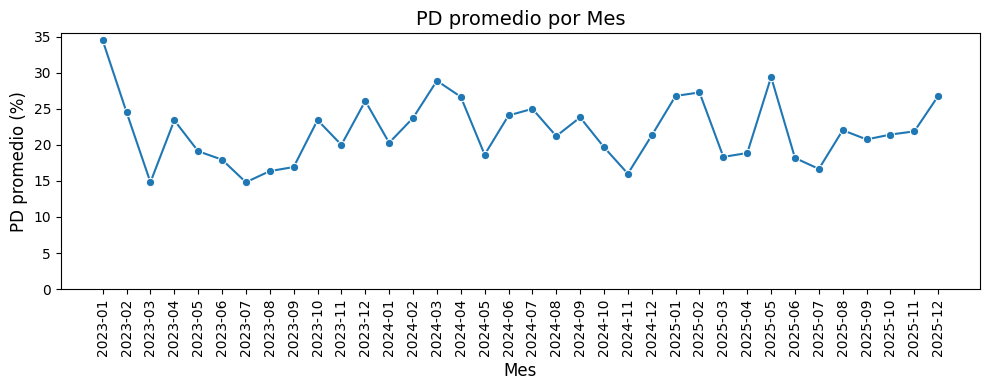

In [4]:
df['Application_Date'] = pd.to_datetime(df['Application_Date'], errors='coerce')
df['Default'] = pd.to_numeric(df['Default'], errors='coerce')

df['mes'] = df['Application_Date'].dt.to_period('M')

pd_m = df.groupby('mes', as_index=False)['Default'].mean().sort_values('mes')
pd_m['PD_%'] = pd_m['Default'] * 100
pd_m['mes_str'] = pd_m['mes'].astype(str)

plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=pd_m, x='mes_str', y='PD_%', marker='o')
ax.set_title("PD promedio por Mes", fontsize=14)
ax.set_xlabel("Mes", fontsize=12)
ax.set_ylabel("PD promedio (%)", fontsize=12)
plt.xticks(rotation=90)
ax.set_ylim(bottom=0)      
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'Customer_ID'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Income_INR'}>,
        <Axes: title={'center': 'Employment_Years'}>,
        <Axes: title={'center': 'Credit_History_Length'}>],
       [<Axes: title={'center': 'Outstanding_Loans'}>,
        <Axes: title={'center': 'Loan_Amount'}>,
        <Axes: title={'center': 'Loan_Tenure_Months'}>,
        <Axes: title={'center': 'Savings_Account_Balance'}>,
        <Axes: title={'center': 'Checking_Account_Balance'}>],
       [<Axes: title={'center': 'No_of_Open_Accounts'}>,
        <Axes: title={'center': 'No_of_Closed_Accounts'}>,
        <Axes: title={'center': 'Total_Credit_Limit'}>,
        <Axes: title={'center': 'Total_Current_Balance'}>,
        <Axes: title={'center': 'Credit_Utilization_Ratio'}>],
       [<Axes: title={'center': 'No_of_Inquiries_6M'}>,
        <Axes: title={'center': 'No_of_Inquiries_12M'}>,
        <Axes: title={'center': 'DPD_30'}>,
        <Axes

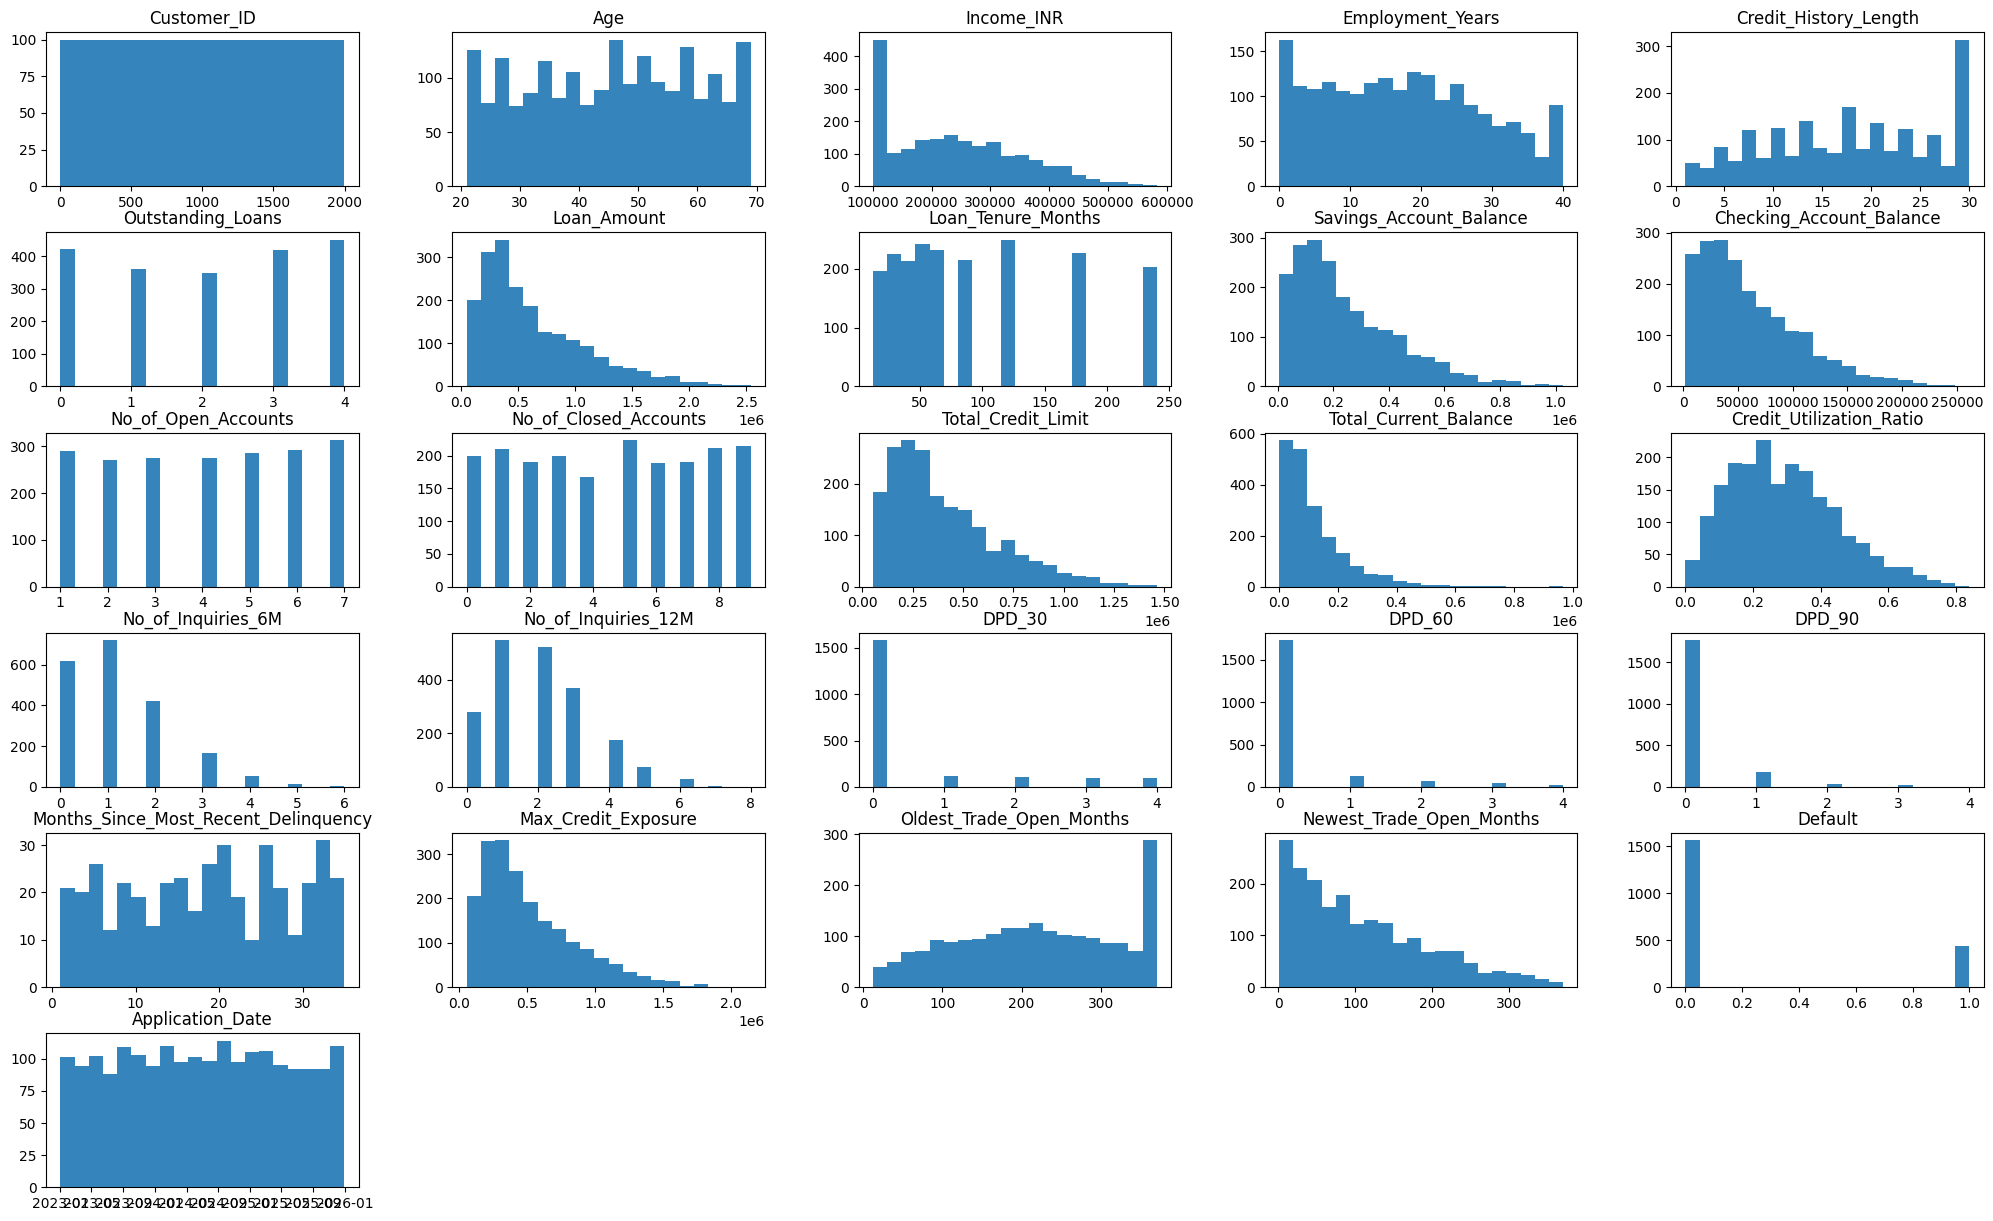

In [5]:
df.hist(bins=20, figsize=(25,15), alpha=0.9, grid=False)

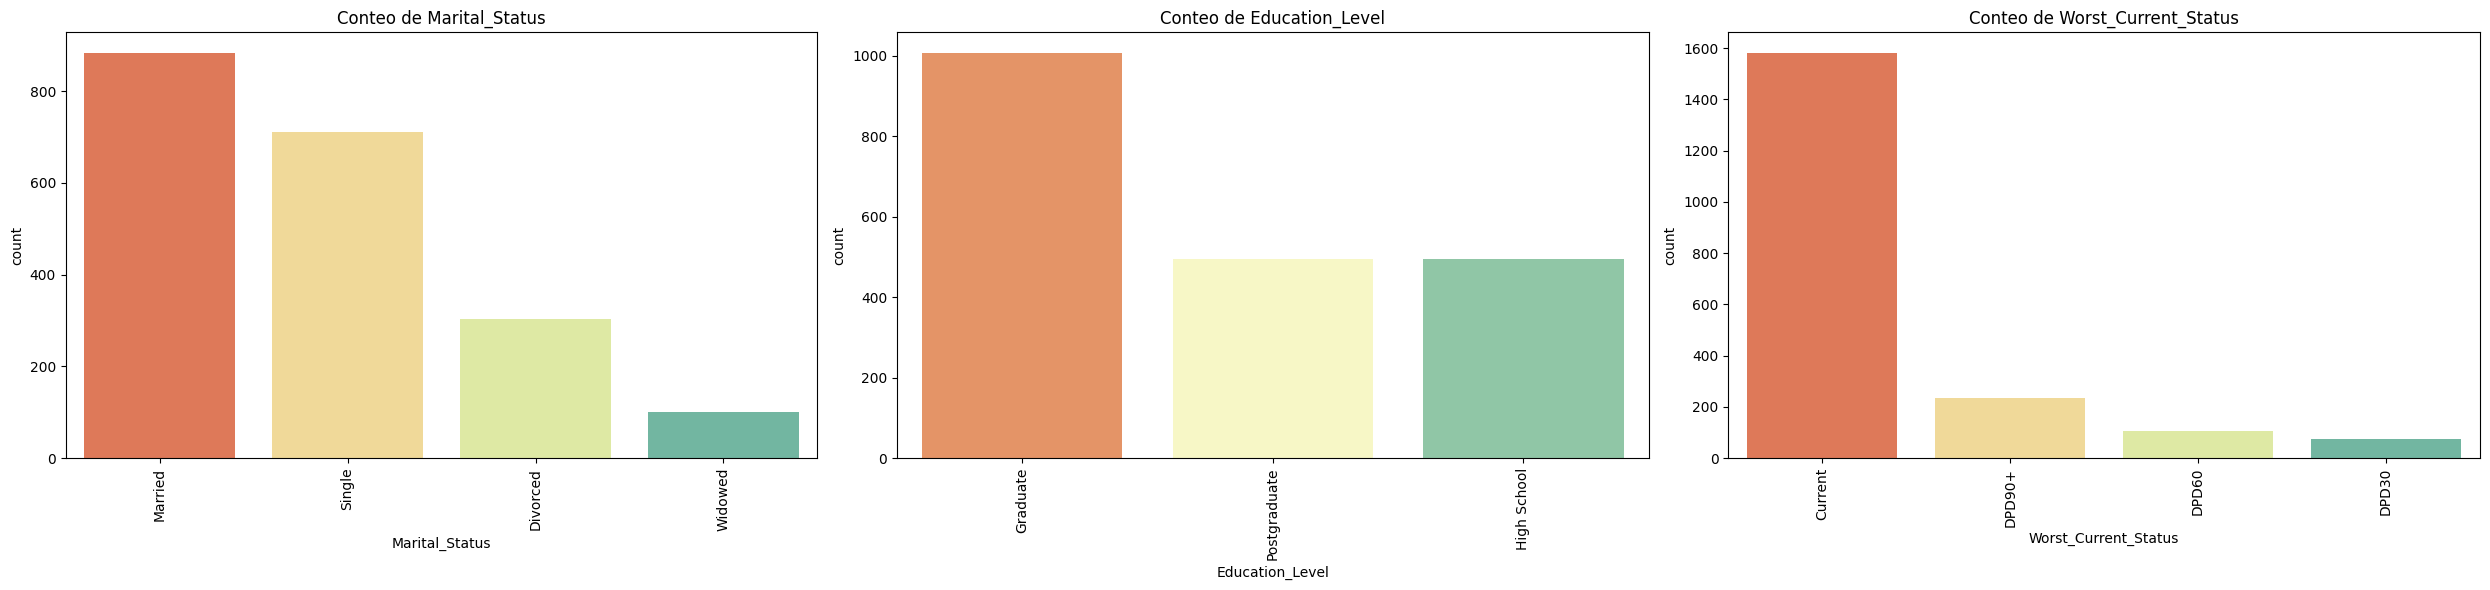

In [8]:
v_cat = df.select_dtypes(include='object').columns.tolist()


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(25, 6))
axes_flat = axes.flatten() 

for i, col in enumerate(v_cat):
    ax = axes_flat[i]
    sns.countplot(data=df, x=col, ax=ax, palette="Spectral")
    ax.set_title(f'Conteo de {col}')
    ax.tick_params(axis='x', rotation=90) 

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

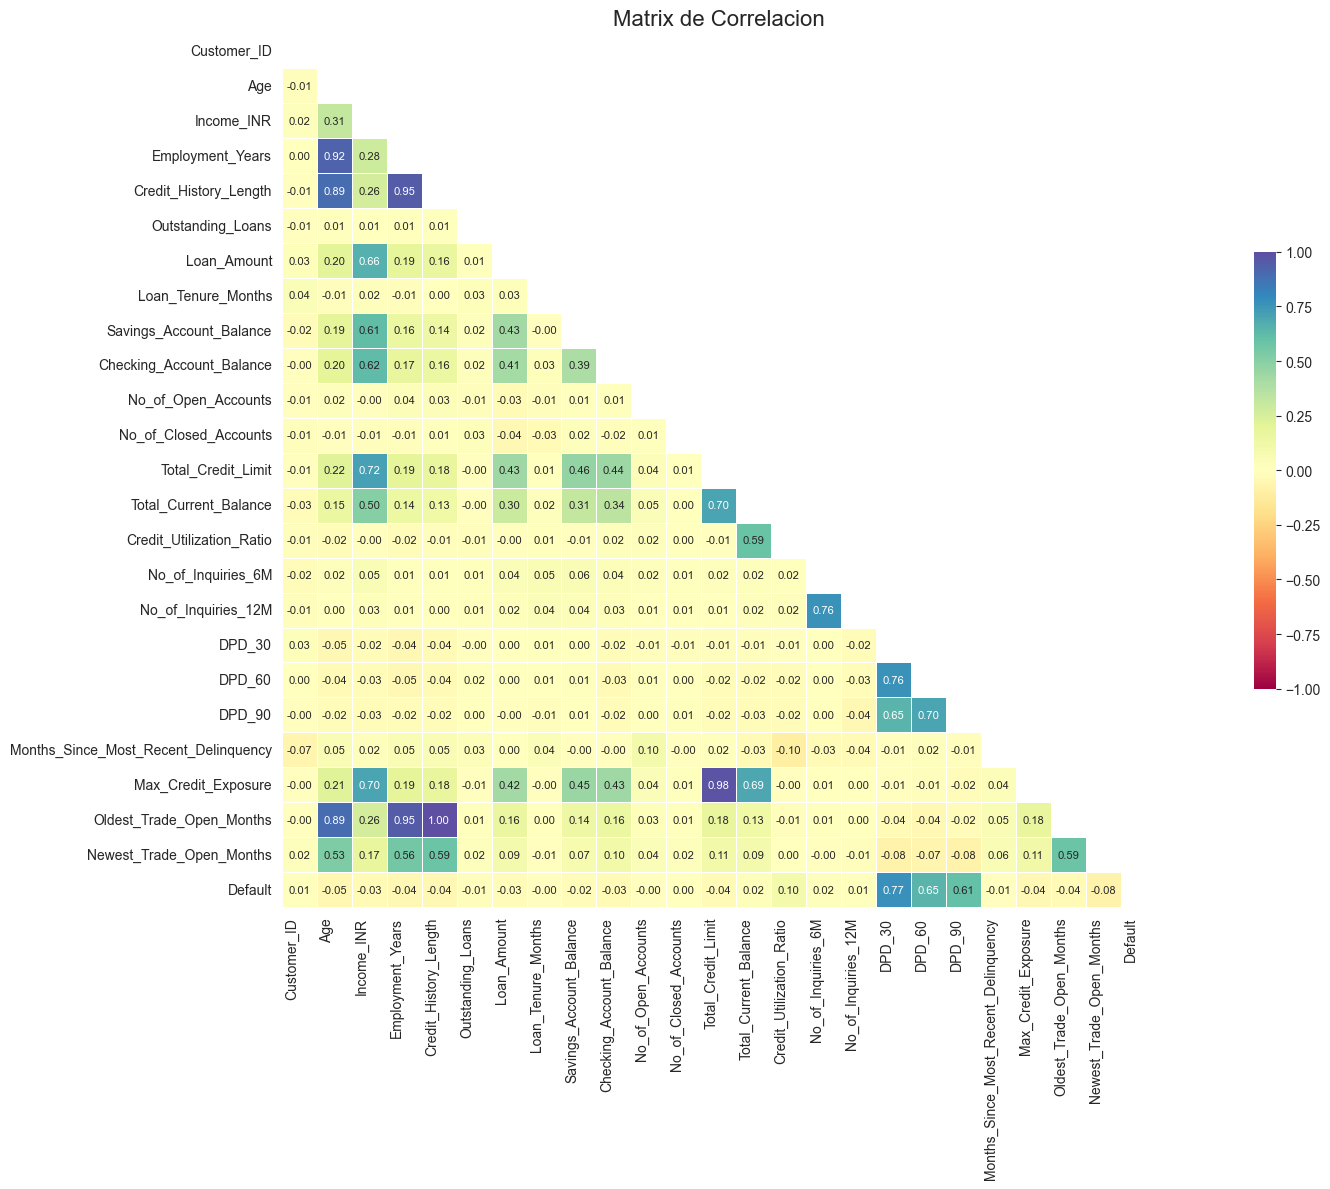

In [10]:
v_num = df.select_dtypes(include='number').columns.tolist()

corr = df[v_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 12))
sns.set_style("white")  

sns.heatmap(corr, mask=mask, cmap="Spectral", 
            vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 8}, linewidths=0.5,
            cbar_kws={"shrink": 0.5, "aspect": 20}, linecolor='white')

plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.title("Matrix de Correlacion", fontsize=16)
plt.tight_layout()
plt.show()